# Inference and Evaluation of Saccharomyces Cerevisiae FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on Saccharomyces Cerevisiae - yeast9 metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

In [2]:
import os
import random
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from yeast9_transformer import load_data, prepare_tensors, set_seed
from flux_transformer import FluxTransformer

%matplotlib inline
pd.set_option('display.max_rows', None)

In [3]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [4]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")

    if log_scale:
        plt.yscale('log')
        
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [5]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    label_map = {
        'r_2111': 'Biomass Yeast9',
        'r_1110': 'ADP/ATP transporter',
        'r_2100': 'water exchange',
        'r_1672': 'carbon dioxide exchange',
    }
    display_label = label_map.get(display_label, display_label)

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot (top-right): center around y=0
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
    if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
        res_abs_max = 1.0
    axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    axs[0, 1].grid(True)

    # Error distribution (bottom-left): center around x=0
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].axvline(x=0, color='r', linestyle='-')
    err_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
    if (not np.isfinite(err_abs_max)) or (err_abs_max == 0.0):
        err_abs_max = 1.0
    axs[1, 0].set_xlim(-err_abs_max, err_abs_max)
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()
    plt.close()

In [6]:
def plot_flux(
    model,
    X_test,
    y_test, 
    input_cols,
    output_cols,
    flux_name: str,
    save_path=None,
    batch_size=16,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Plotting for a single flux column.
    """

    # find target column index
    try:
        target_idx = output_cols.index(flux_name) + len(input_cols)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    print(f"Plotting flux '{flux_name}' (column index {target_idx})")

    model = model.to(device)
    model.eval()

    pred_vals = []
    true_vals = []

    with torch.no_grad():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i+batch_size].to(device)
            yb_true = y_test[i:i+batch_size]

            c = xb.unsqueeze(-1)

            yb_pred = model(c)

            # Slice only the flux we care
            yb_pred_flux = yb_pred.squeeze(-1)[:, target_idx].detach().cpu().numpy()
            yb_true_flux = yb_true[:, target_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.startswith('cuda'):
                torch.cuda.empty_cache()

    # concatenate all batches
    y_pred_flux = np.concatenate(pred_vals, axis=0)
    y_true_flux = np.concatenate(true_vals, axis=0)

    print(f"{flux_name} y_true range: {y_true_flux.min()} .. {y_true_flux.max()}")
    print(f"{flux_name} y_pred range: {y_pred_flux.min()} .. {y_pred_flux.max()}")

    # Per-flux metrics for the currently plotted target
    try:
        r2_flux = r2_score(y_true_flux, y_pred_flux)
    except Exception:
        r2_flux = float('nan')
    mae_flux = mean_absolute_error(y_true_flux, y_pred_flux)
    rmse_flux = np.sqrt(np.mean((y_true_flux - y_pred_flux) ** 2))
    print(f"R2: {r2_flux:.4f}")
    print(f"MAE: {mae_flux:.6f}")
    print(f"RMSE: {rmse_flux:.6f}")

    plot_diagnostics_2x2(
        y_true=y_true_flux,
        y_pred=y_pred_flux,
        label=flux_name,
        save_path=save_path
    )


### Load model

In [7]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
model_name = "yeast9_d256_h8_l3_ff1024"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d256_h8_l3_ff1024/yeast9_d256_h8_l3_ff1024_checkpoint.pth
Configuration: d_model=256, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 3,449,377

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


### Load data

In [9]:
# Load data using the same function as during training
set_seed()

DATA_PATH = f"./data/yeast9_test_data.csv"

#X, y, input_cols, output_cols = load_data(data_info['dataset'])
X, y, input_cols, output_cols = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)


Loaded data with 49393 samples from ./data/yeast9_test_data.csv
Number of input features: 64
Number of output targets: 4131
Training samples: 39514
Test samples: 9879


In [10]:
model.eval()

FluxTransformer(
  (input_embedding): Embedding(4195, 256)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((257,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=257, out_features=1024, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=1024, out_features=257, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

### Plot Results

In [11]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

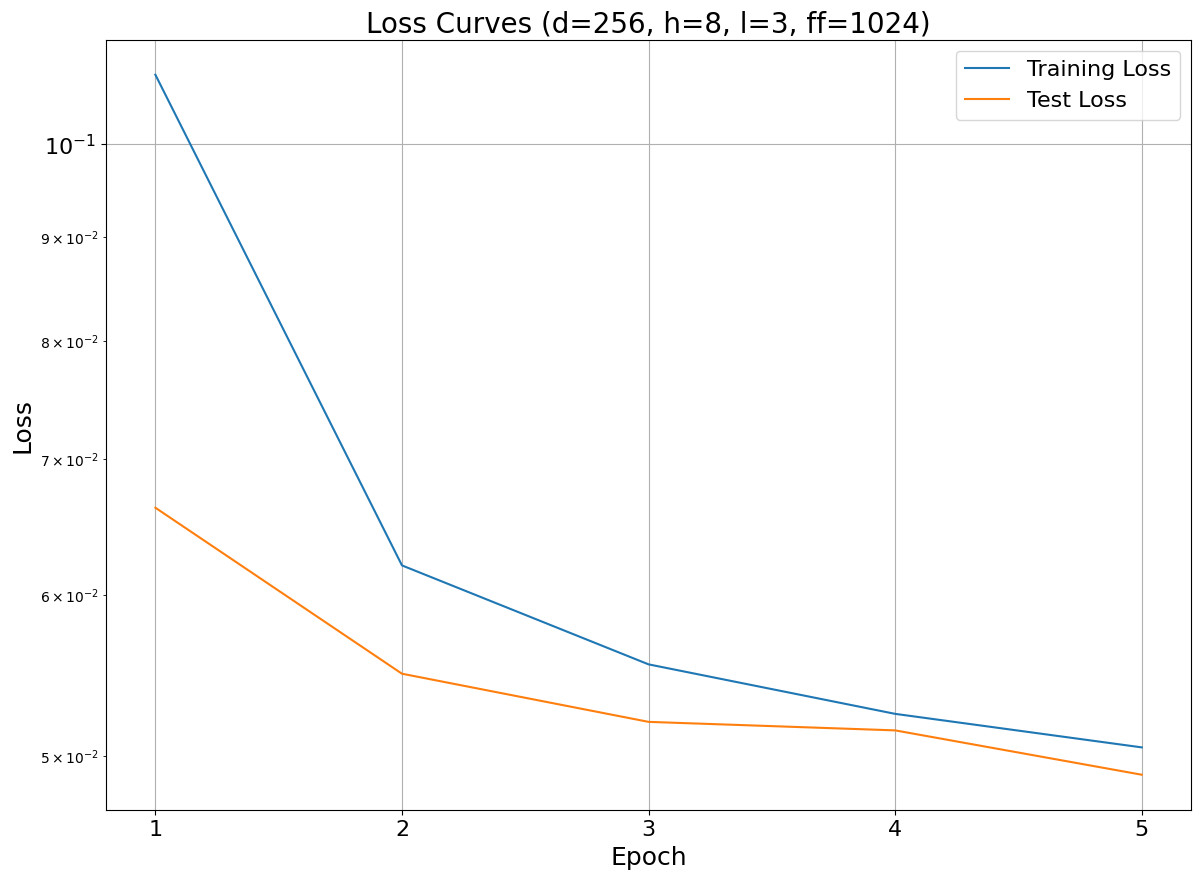

In [12]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
    )

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: 0.031713396310806274 .. 2.8635923862457275
R2: 0.9858
MAE: 0.052342
RMSE: 0.066970


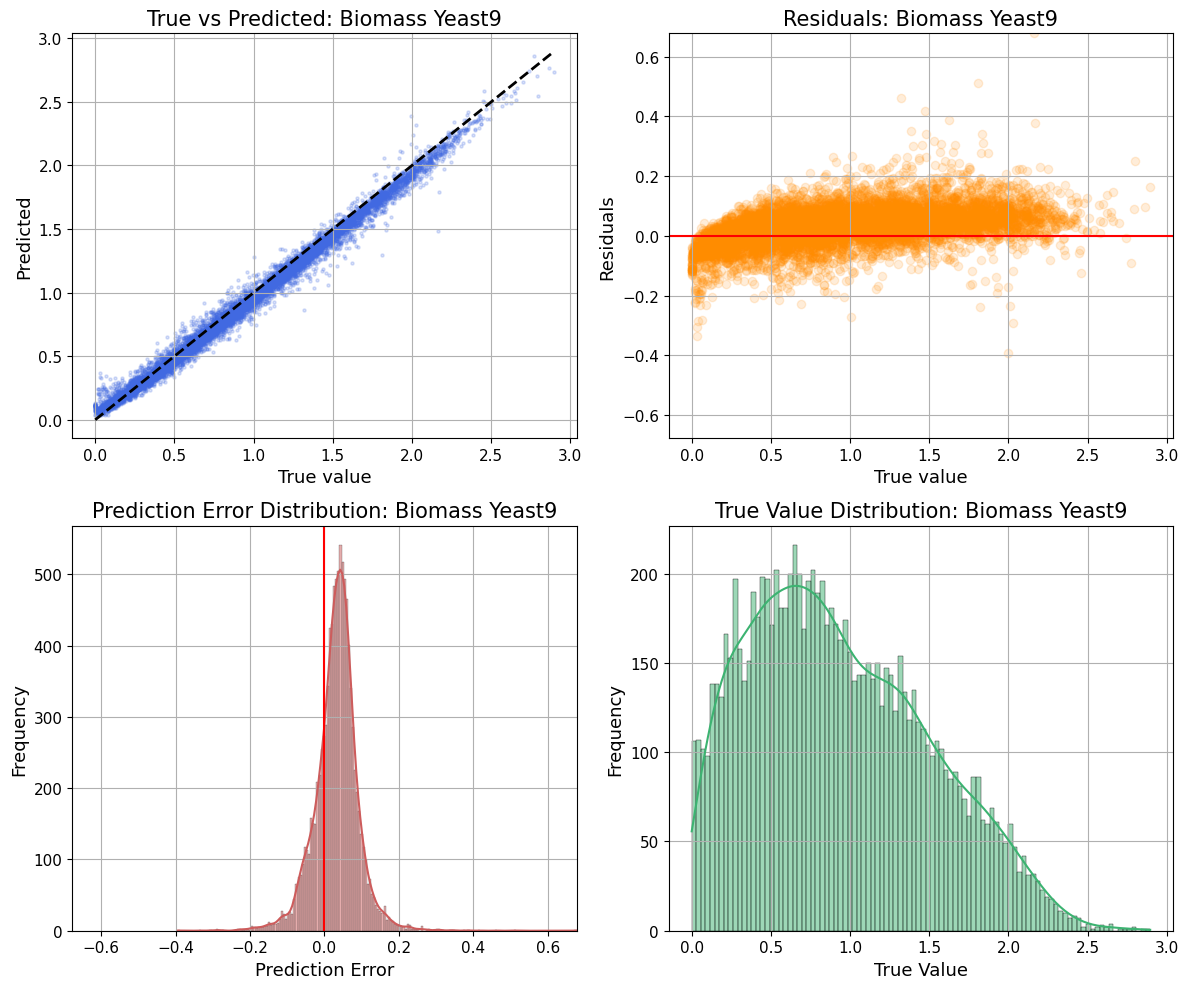

r_1110:
------------------------------------------------------------
Plotting flux 'r_1110' (column index 923)
r_1110 y_true range: 0.0 .. 150.24110412597656
r_1110 y_pred range: 0.4117259979248047 .. 147.9962158203125
R2: 0.9923
MAE: 1.534296
RMSE: 3.083488


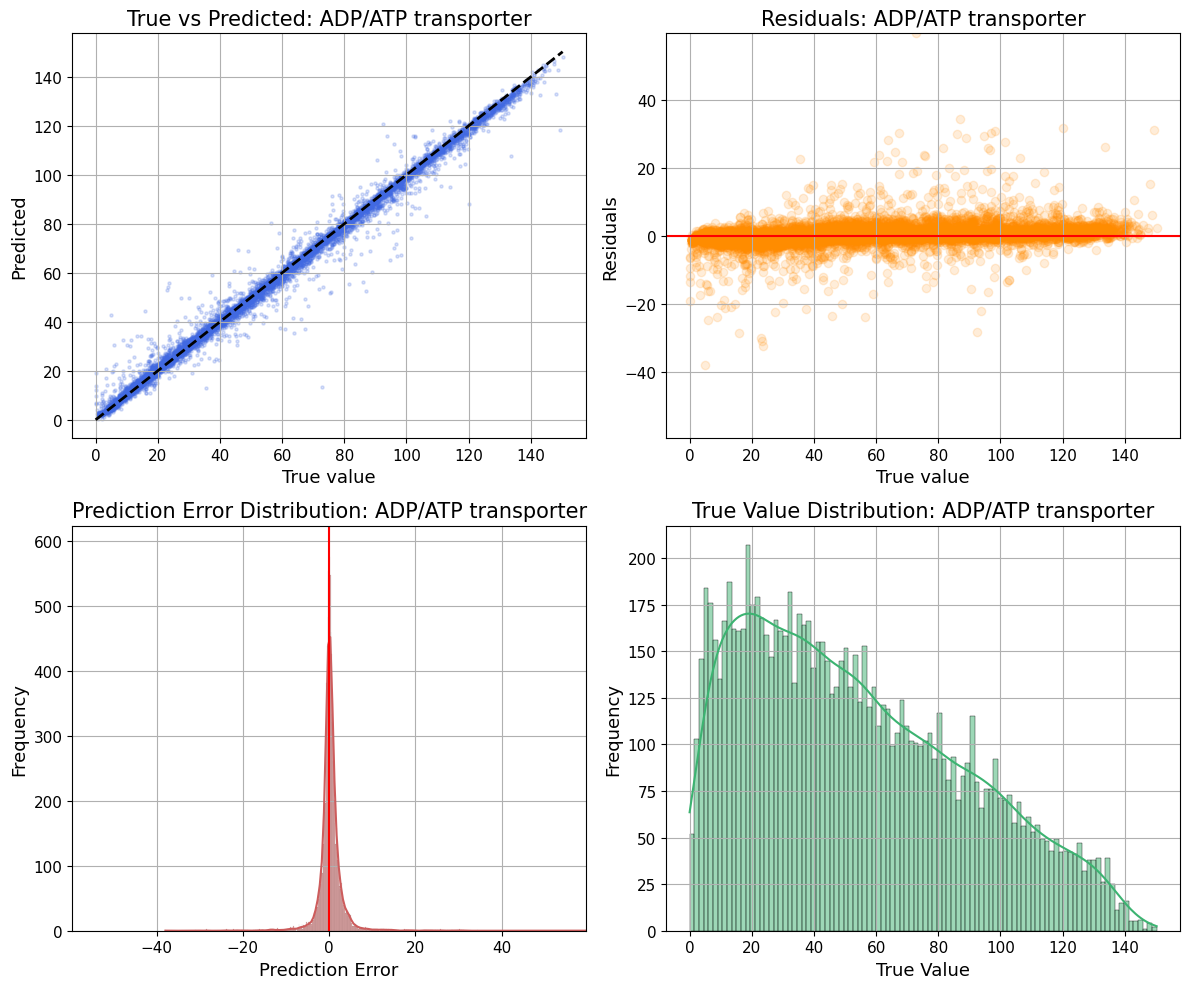

In [13]:
# r_2111: growth
# r_0438: ferrocytochrome-c:oxygen oxidoreductase
# r_1110: ADP/ATP transporter
diagnostics_to_plot = ['r_2111', 'r_1110']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

In [14]:
'''
# Amino acids
# r_1810: L-glycine exchange
# r_1873: L-alanine exchange
# r_1889: L-glutamate exchange
diagnostics_to_plot = ['r_1810', 'r_1873', 'r_1889']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)
'''

'\n# Amino acids\n# r_1810: L-glycine exchange\n# r_1873: L-alanine exchange\n# r_1889: L-glutamate exchange\ndiagnostics_to_plot = [\'r_1810\', \'r_1873\', \'r_1889\']\n\nfor flux_name in diagnostics_to_plot:\n    print(f\'{flux_name}:\')\n    print(60 * \'-\')\n    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)\n'

r_2100:
------------------------------------------------------------
Plotting flux 'r_2100' (column index 1554)
r_2100 y_true range: -16.682891845703125 .. 104.28714752197266
r_2100 y_pred range: -15.339838027954102 .. 98.41114807128906
R2: 0.9823
MAE: 1.509954
RMSE: 2.861032


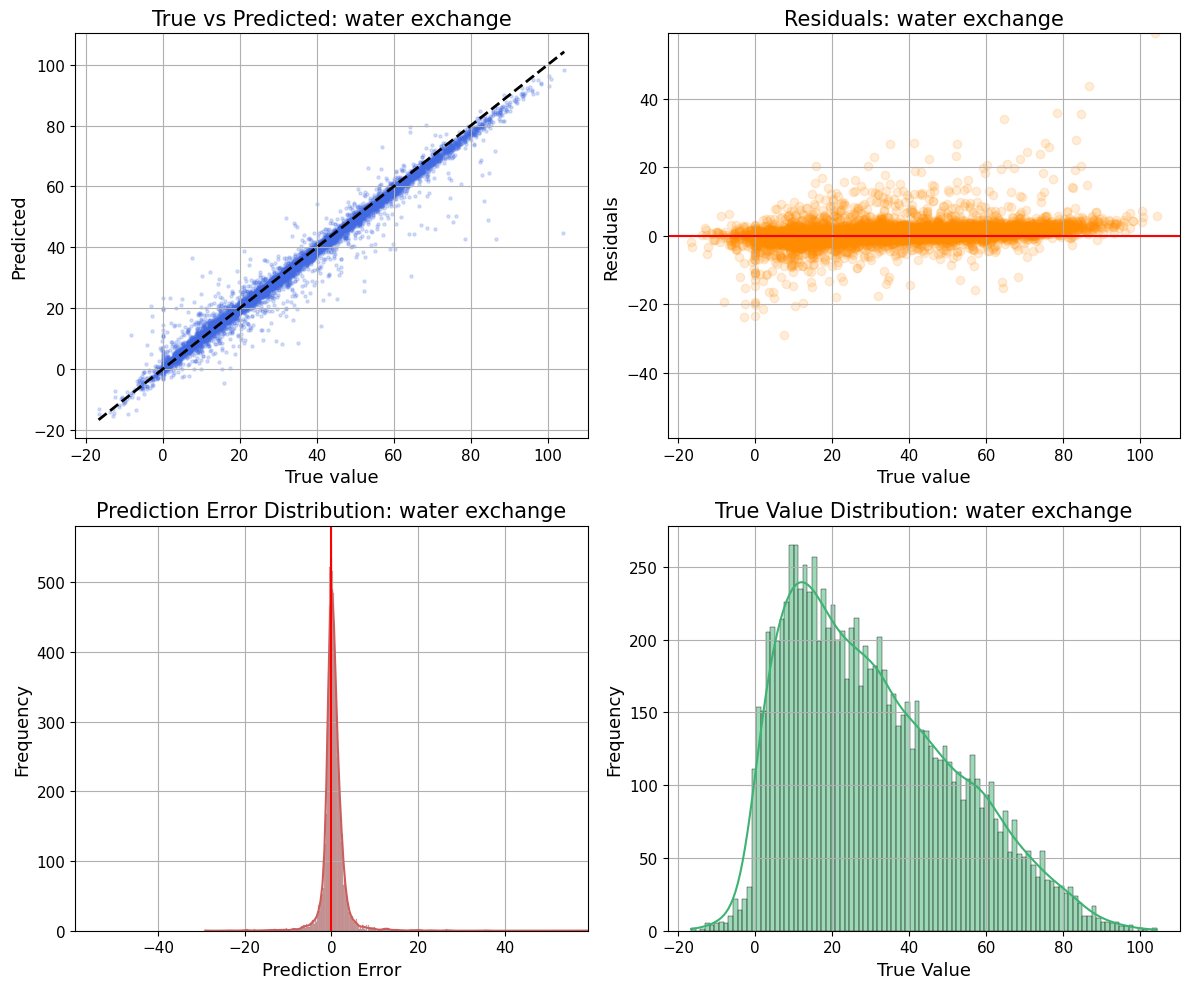

r_1672:
------------------------------------------------------------
Plotting flux 'r_1672' (column index 1204)
r_1672 y_true range: 0.22407589852809906 .. 148.4969024658203
r_1672 y_pred range: 0.705876350402832 .. 132.082763671875
R2: 0.9804
MAE: 1.855468
RMSE: 3.153743


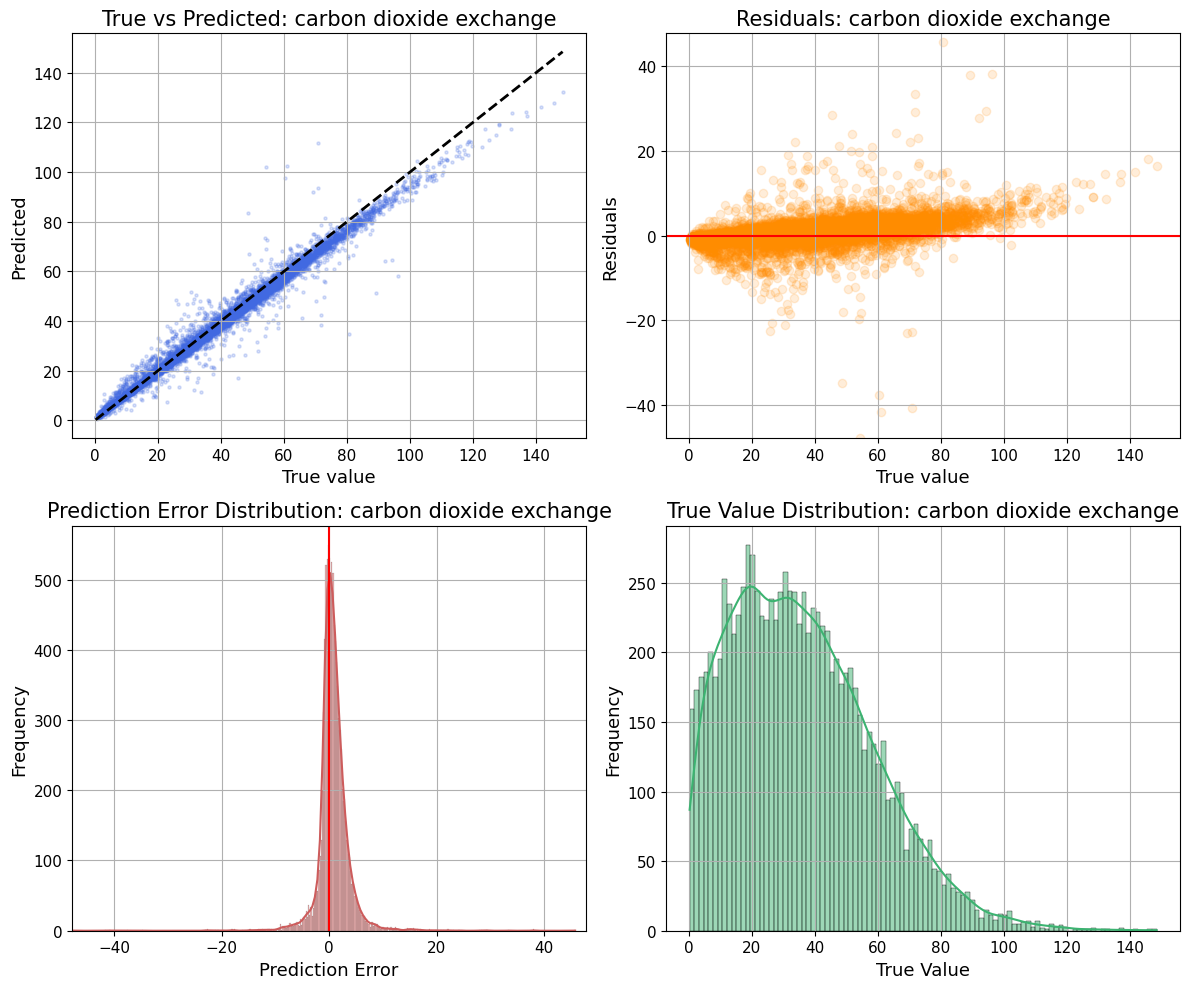

In [15]:
# r_2100	water exchange
# r_1672	carbon dioxide exchange

diagnostics_to_plot = ['r_2100', 'r_1672']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

In [16]:
# Overall test-set metrics across all model outputs (output_cols)
model = model.to(device)
model.eval()

pred_batches = []
true_batches = []
start_idx = len(input_cols)
end_idx = len(input_cols) + len(output_cols)

with torch.no_grad():
    for i in range(0, X_test.shape[0], 32):
        xb = X_test[i:i+32].to(device)
        yb_true = y_test[i:i+32]

        c = xb.unsqueeze(-1)
        yb_pred = model(c).squeeze(-1).detach().cpu().numpy()
        yb_true_np = yb_true.detach().cpu().numpy()

        pred_batches.append(yb_pred[:, start_idx:end_idx])
        true_batches.append(yb_true_np[:, start_idx:end_idx])

        if str(device).startswith('cuda'):
            torch.cuda.empty_cache()

y_pred_all = np.concatenate(pred_batches, axis=0)
y_true_all = np.concatenate(true_batches, axis=0)

r2_overall = r2_score(y_true_all, y_pred_all)
mae_overall = mean_absolute_error(y_true_all, y_pred_all)
rmse_overall = np.sqrt(np.mean((y_true_all - y_pred_all) ** 2))

print('Overall model metrics (all output_cols):')
print(f'R2:   {r2_overall:.4f}')
print(f'MAE:  {mae_overall:.6f}')
print(f'RMSE: {rmse_overall:.6f}')


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.78 GiB. GPU 0 has a total capacity of 8.00 GiB of which 4.68 GiB is free. Of the allocated memory 2.21 GiB is allocated by PyTorch, and 33.00 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)